# Handwritten CharacterRecognition

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


In [3]:
df = pd.read_csv("A_Z Handwritten Data.csv")

# La première colonne contient les labels (de 0 à 25 correspondant à A-Z)
X = df.drop('0', axis=1)
y = df['0']

print("Shape of data:", X.shape)


Shape of data: (372450, 784)


In [4]:
df

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372445,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372446,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372447,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372448,25,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: int64(785)
memory usage: 2.2 GB


In [7]:
df.describe()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
count,372450.000000,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,...,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000
mean,13.523490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001616,0.001592,0.001117,0.000929,0.000685,0.000596,0.000618,0.000690,0.000239,0.000011
std,6.740824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.490788,0.517297,0.421332,0.419180,0.385566,0.319820,0.208942,0.335227,0.134852,0.006554
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,252.000000,226.000000,229.000000,228.000000,235.000000,194.000000,103.000000,198.000000,82.000000,4.000000


In [8]:
df.isnull().sum()

0        0
0.1      0
0.2      0
0.3      0
0.4      0
        ..
0.644    0
0.645    0
0.646    0
0.647    0
0.648    0
Length: 785, dtype: int64

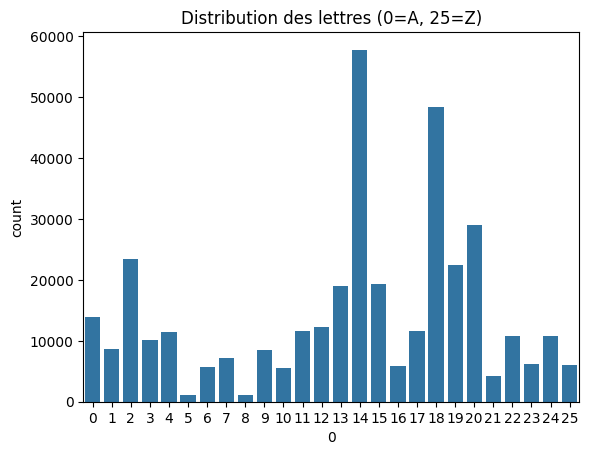

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Distribution des lettres (0=A, 25=Z)")
plt.show()


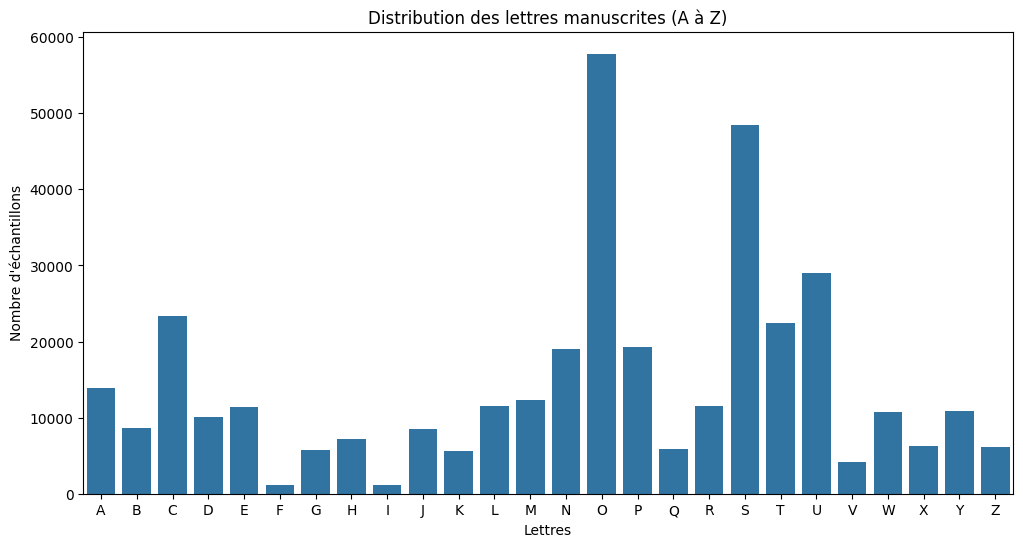

In [10]:
import string

# Mapper les labels numériques aux lettres alphabétiques
label_mapping = {i: letter for i, letter in enumerate(string.ascii_uppercase)}
y_letters = y.map(label_mapping)

# Plot
plt.figure(figsize=(12,6))
sns.countplot(x=y_letters, order=sorted(y_letters.unique()))
plt.title("Distribution des lettres manuscrites (A à Z)")
plt.xlabel("Lettres")
plt.ylabel("Nombre d'échantillons")
plt.show()


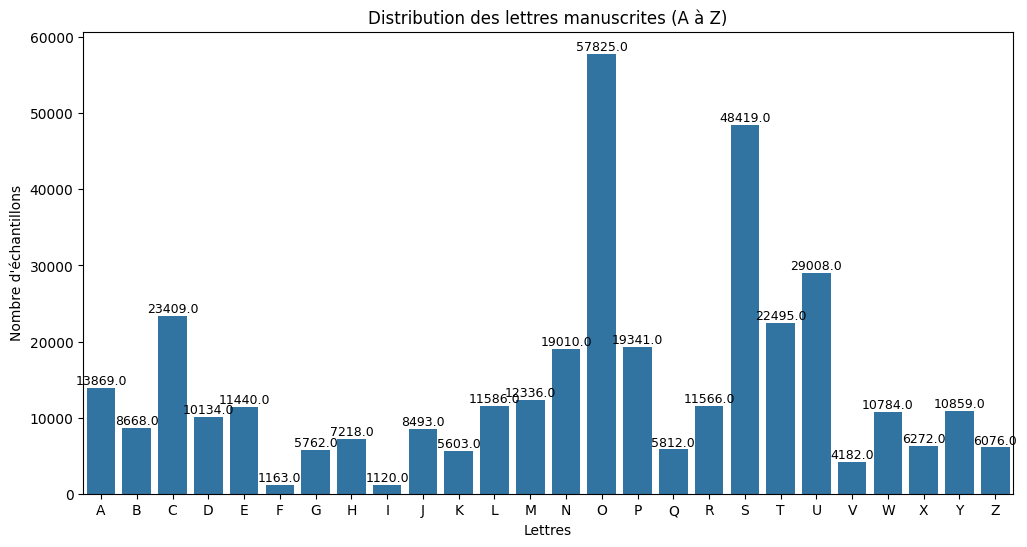

In [11]:
plt.figure(figsize=(12,6))
ax = sns.countplot(x=y_letters, order=sorted(y_letters.unique()))
plt.title("Distribution des lettres manuscrites (A à Z)")
plt.xlabel("Lettres")
plt.ylabel("Nombre d'échantillons")

# Ajouter les annotations sur les barres
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=9, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()


In [12]:
value_counts = y.value_counts().sort_index()
for i, count in value_counts.items():
    print(f"Lettre {label_mapping[i]} ({i}) : {count} échantillons")

Lettre A (0) : 13869 échantillons
Lettre B (1) : 8668 échantillons
Lettre C (2) : 23409 échantillons
Lettre D (3) : 10134 échantillons
Lettre E (4) : 11440 échantillons
Lettre F (5) : 1163 échantillons
Lettre G (6) : 5762 échantillons
Lettre H (7) : 7218 échantillons
Lettre I (8) : 1120 échantillons
Lettre J (9) : 8493 échantillons
Lettre K (10) : 5603 échantillons
Lettre L (11) : 11586 échantillons
Lettre M (12) : 12336 échantillons
Lettre N (13) : 19010 échantillons
Lettre O (14) : 57825 échantillons
Lettre P (15) : 19341 échantillons
Lettre Q (16) : 5812 échantillons
Lettre R (17) : 11566 échantillons
Lettre S (18) : 48419 échantillons
Lettre T (19) : 22495 échantillons
Lettre U (20) : 29008 échantillons
Lettre V (21) : 4182 échantillons
Lettre W (22) : 10784 échantillons
Lettre X (23) : 6272 échantillons
Lettre Y (24) : 10859 échantillons
Lettre Z (25) : 6076 échantillons


In [10]:
import string
label_mapping = dict(zip(range(26), string.ascii_uppercase))
df['letter'] = y.map(label_mapping)


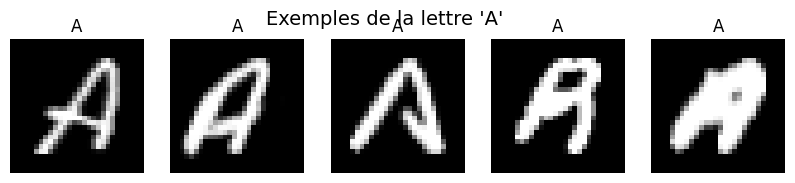

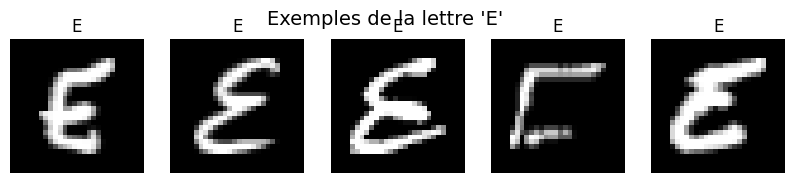

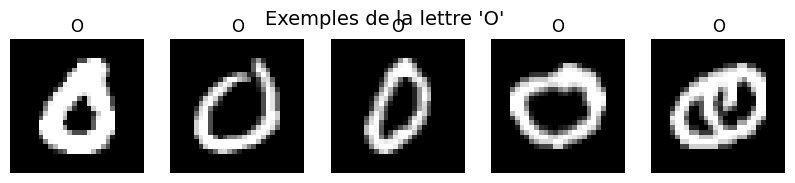

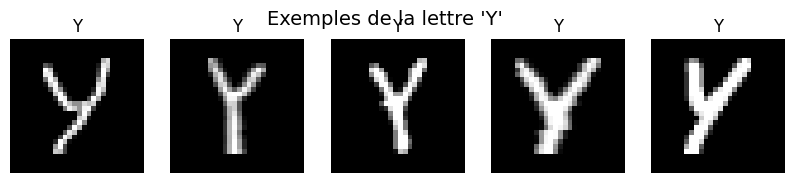

In [14]:
import numpy as np

def show_samples_by_letter(letter_idx, n=5):
    letter = label_mapping[letter_idx]
    indices = y[y == letter_idx].sample(n).index
    plt.figure(figsize=(10,2))
    for i, idx in enumerate(indices):
        image = X.iloc[idx].values.reshape(28, 28)
        plt.subplot(1, n, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f'{letter}')
        plt.axis('off')
    plt.suptitle(f"Exemples de la lettre '{letter}'", fontsize=14)
    plt.show()

# Exemples pour quelques lettres
for i in [0, 4, 14, 24]:  # A, E, O, Y
    show_samples_by_letter(i, n=5)


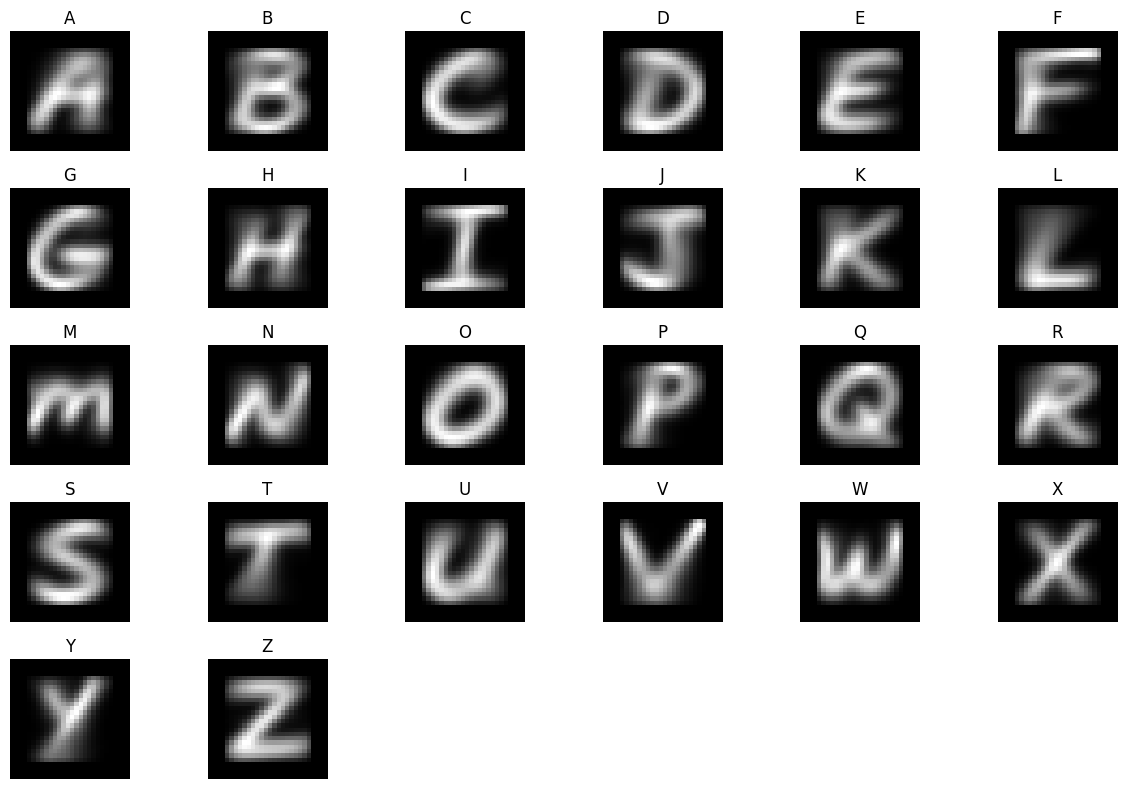

In [15]:
# Calcul de l'image moyenne pour chaque classe
avg_images = np.zeros((26, 28, 28))  # 26 lettres (A-Z)
for i in range(26):
    class_images = X[y == i]
    avg_images[i] = class_images.mean(axis=0).values.reshape(28, 28)

# Afficher les images moyennes pour chaque lettre
plt.figure(figsize=(12, 8))
for i in range(26):
    plt.subplot(5, 6, i+1)
    plt.imshow(avg_images[i], cmap='gray')
    plt.title(f"{chr(i + 65)}")  # Convertit 0 -> A, 1 -> B, ...
    plt.axis('off')
plt.tight_layout()
plt.show()


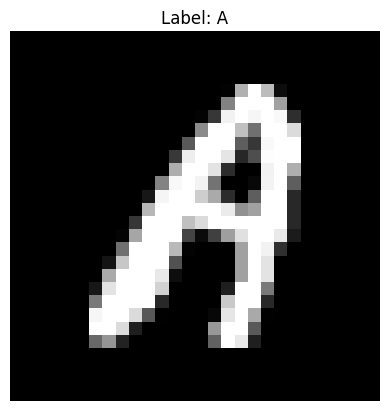

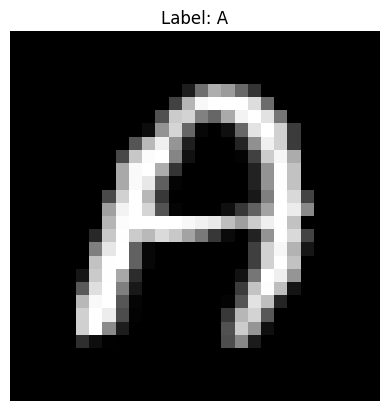

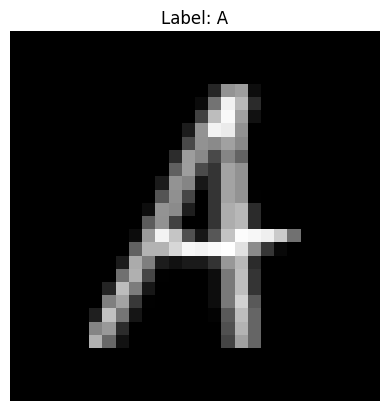

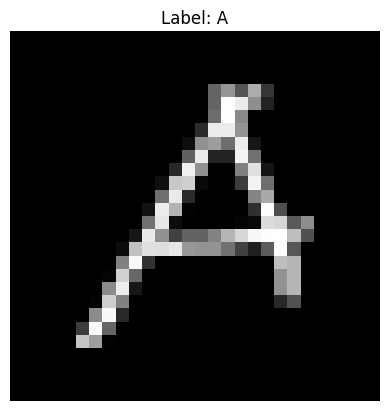

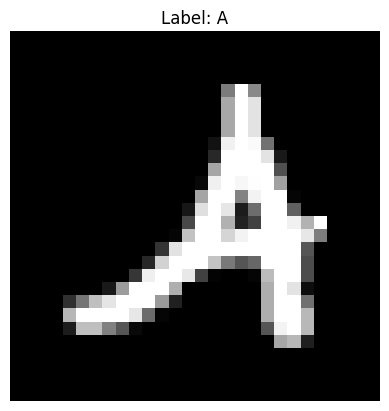

In [16]:
def plot_image(index):
    image = X.iloc[index].values.reshape(28,28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label_mapping[y.iloc[index]]}")
    plt.axis('off')
    plt.show()

for i in range(5):
    plot_image(i)


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


In [19]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = clf.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9881326352530541
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      2774
           1       0.98      0.97      0.98      1734
           2       0.99      1.00      0.99      4682
           3       0.98      0.97      0.97      2027
           4       0.99      0.98      0.99      2288
           5       0.99      0.94      0.96       233
           6       0.99      0.97      0.98      1152
           7       0.98      0.96      0.97      1444
           8       1.00      0.98      0.99       224
           9       0.99      0.98      0.98      1699
          10       0.98      0.97      0.98      1121
          11       1.00      1.00      1.00      2317
          12       0.99      0.98      0.98      2467
          13       0.98      0.99      0.99      3802
          14       0.99      1.00      0.99     11565
          15       0.99      1.00      0.99      3868
          16       0.98      0.94      0.96   

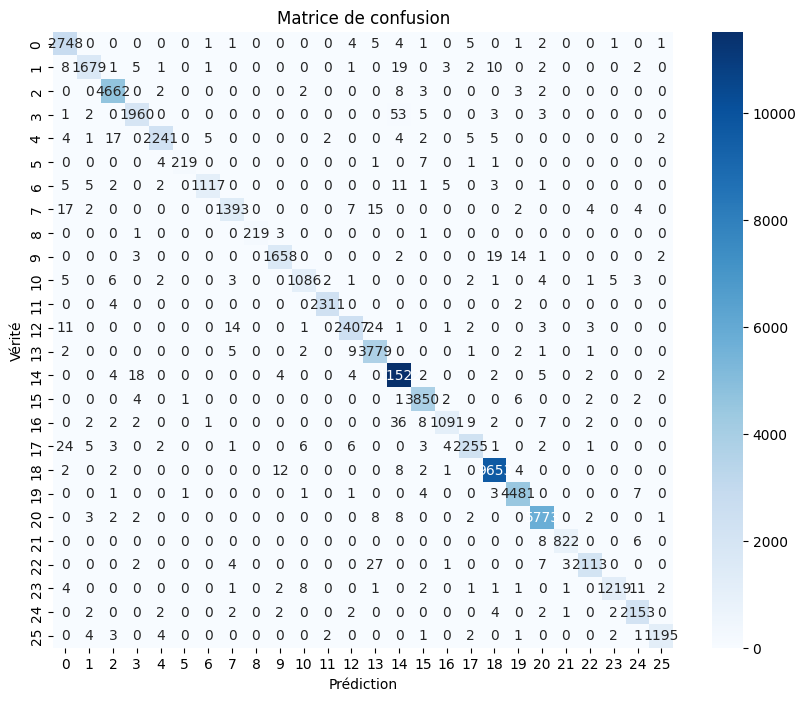

In [21]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vérité")
plt.show()


In [22]:
import joblib

# Enregistrement du modèle
joblib.dump(clf, 'random_forest_model.pkl')

# Pour le recharger plus tard :
# clf = joblib.load('random_forest_model.pkl')


['random_forest_model.pkl']

In [23]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # tu peux tester différents k
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.9607598335347026
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2774
           1       0.98      0.88      0.93      1734
           2       0.95      0.98      0.96      4682
           3       0.95      0.87      0.91      2027
           4       0.97      0.91      0.94      2288
           5       0.93      0.90      0.92       233
           6       0.97      0.88      0.92      1152
           7       0.93      0.93      0.93      1444
           8       0.98      0.87      0.92       224
           9       0.94      0.92      0.93      1699
          10       0.94      0.91      0.93      1121
          11       0.92      0.99      0.95      2317
          12       0.99      0.97      0.98      2467
          13       0.95      0.97      0.96      3802
          14       0.96      0.99      0.97     11565
          15       0.92      0.98      0.95      3868
          16       0.97      0.76      0.85     

In [24]:
import joblib

# Enregistrement du modèle
joblib.dump(clf, 'knn_model.pkl')


['knn_model.pkl']

In [25]:
# === Modèle SVM (avec sous-échantillon) ===
from sklearn.svm import LinearSVC

# Prendre un sous-échantillon pour accélérer le fit du SVM
from sklearn.utils import resample

X_train_small, _, y_train_small, _ = train_test_split(X_train, y_train, train_size=0.2, stratify=y_train, random_state=42)

svm = LinearSVC(dual=False, max_iter=5000)
svm.fit(X_train_small, y_train_small)
y_pred_svm = svm.predict(X_test)

print("=== SVM (LinearSVC) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM (LinearSVC) ===
Accuracy: 0.845858504497248
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      2774
           1       0.78      0.69      0.74      1734
           2       0.88      0.90      0.89      4682
           3       0.78      0.68      0.73      2027
           4       0.80      0.77      0.79      2288
           5       0.86      0.79      0.82       233
           6       0.83      0.68      0.75      1152
           7       0.71      0.58      0.64      1444
           8       0.74      0.77      0.75       224
           9       0.75      0.63      0.68      1699
          10       0.72      0.71      0.71      1121
          11       0.90      0.94      0.92      2317
          12       0.84      0.87      0.86      2467
          13       0.76      0.78      0.77      3802
          14       0.90      0.96      0.93     11565
          15       0.87      0.89      0.88      3868
          16       0.83      

In [26]:
import joblib

joblib.dump(svm, 'svm_model.pkl')

['svm_model.pkl']